# h-fix methods comparison — h-vector grid

Compares every cn_full / EM-weighting strategy tried for the cactus-vs-PG h imbalance.

**Columns:** `g0_n231` (truth uniform 0.346) · `g0_n50 cactus-heavy` (truth cactus 0.80) · `SEEDMIX` (real, x = hapFIRE 8-rep avg).
**Rows:** methods. Blue = cactus founders, orange = PG, dashed = y=x. Title = cactus-mass / RMSE.

Reading: blue above the diagonal = cactus over-credit (filt2); blue on the diagonal = balanced; collapse in the
g0_n50_cact column = uniform-shrinkage artifact (down-weight-rare). Winner = per-bubble-on-subsampMedian (tightest diagonal all 3 cols).


wrote /global/scratch/users/tbellg/kmate/notebooks/plots/H_VECTOR_grid_methods.png


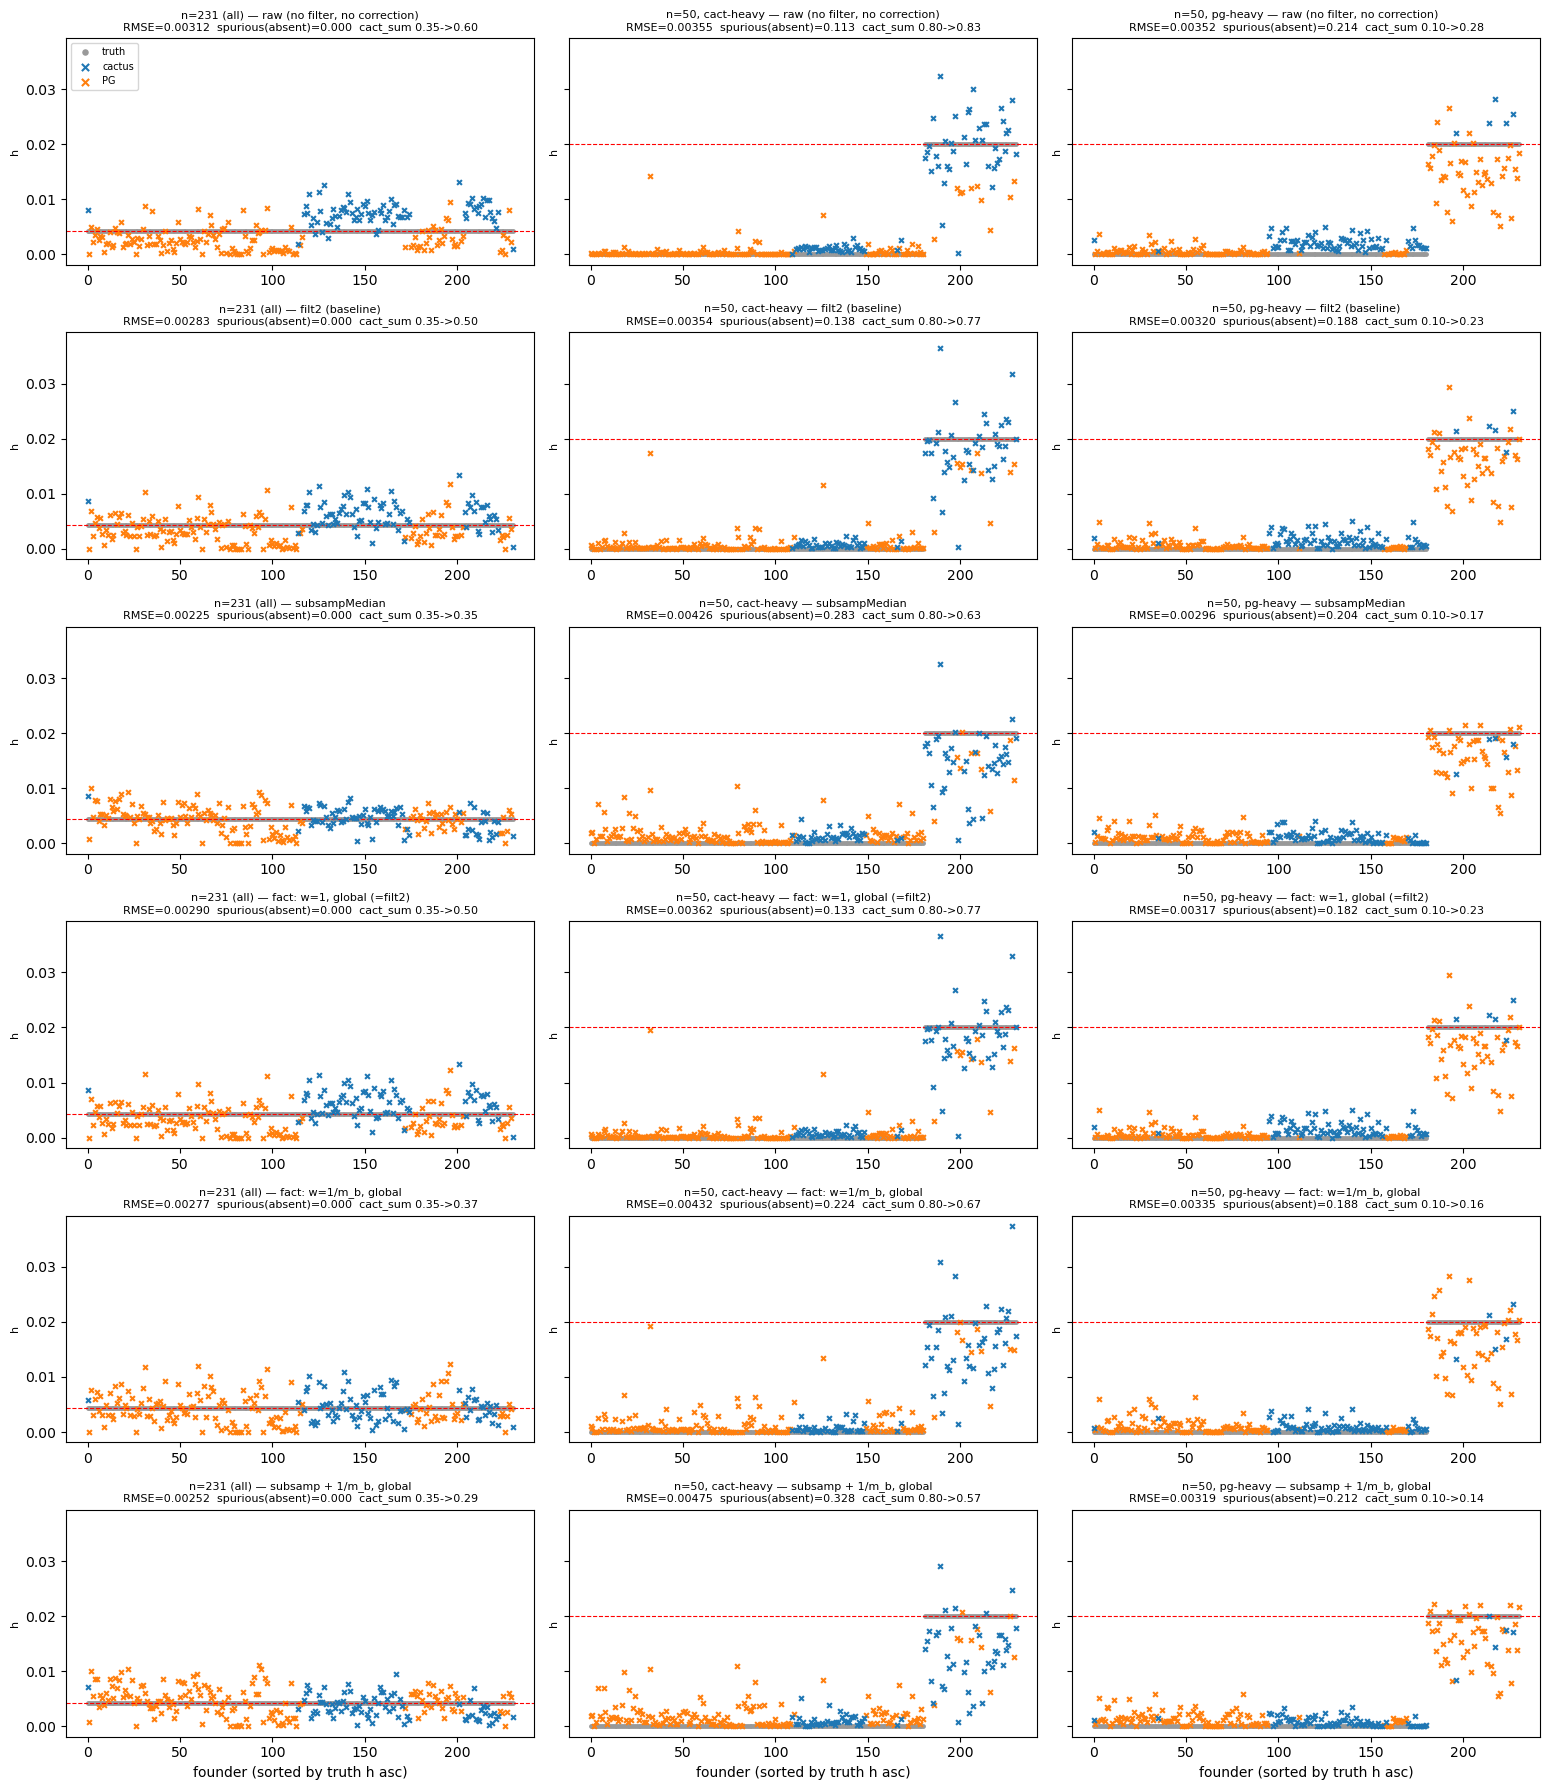

In [1]:
#!/usr/bin/env python3
"""H-vector grid, 'sorted-by-truth' style. cols=[g0_n231, g0_n50_cact, SEEDMIX], rows=methods.
x = founder rank sorted by truth h ascending (hapFIRE for SEEDMIX); gray=truth, blue=cactus est,
orange=PG est, dashed=present-founder truth level. Title: regime/method + MAE, spurious_h(absent),
cact_sum truth->est."""
import numpy as np, csv, json, math, glob, os
import matplotlib; import matplotlib.pyplot as plt

ROOT="/global/scratch/users/tbellg/kmate"; HF=f"{ROOT}/scratch/h_fixes"
G0S="g0_sweep_h_test"; SMD="seedmix_h_test"
CAC=set(map(str,json.load(open(f"{ROOT}/data/founder_split_cactus_pg.json"))["cactus"]))
truth={}
for d in csv.DictReader(open(f"{ROOT}/scratch/g0_sweep_per_founder.tsv"),delimiter="\t"):
    truth.setdefault(d["sim"],{})[d["founder"]]=float(d["truth"])
hf_reps=[]
for s in range(1,9):
    p=f"/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s{s}_ecotype_frequency.txt"
    if os.path.exists(p):
        hd={}
        for ln in open(p):
            q=ln.split()
            if len(q)>=2:
                try: hd[q[0]]=float(q[1])
                except: pass
        hf_reps.append(hd)

def ex(d,kind):
    if kind=="h": return np.asarray(d["h"]).astype(float)
    if kind=="alpha0": return np.asarray(d["h_per_alpha"])[0].astype(float)
    if kind.startswith("g:"): return np.asarray(d["h_per_gamma"])[int(kind[2:])].astype(float)
    if kind.startswith("r:"): return np.asarray(d["h_per_rho"])[int(kind[2:])].astype(float)
    if kind.startswith("k:"): return np.asarray(d[kind[2:]]).astype(float)

M=[
 ("raw (no filter, no correction)", lambda s:f"{ROOT}/scratch/{G0S}/raw_{s}.h_sweep.npz", f"{ROOT}/scratch/{SMD}/raw_S*.h_sweep.npz","alpha0"),
 ("filt2 (baseline)", lambda s:f"{ROOT}/scratch/{G0S}/filt2_{s}.h_sweep.npz", f"{ROOT}/scratch/{SMD}/filt2_S*.h_sweep.npz","alpha0"),
 ("subsampMedian", lambda s:f"{ROOT}/scratch/{G0S}/subsamp_{s}.h_sweep.npz", f"{ROOT}/scratch/{SMD}/subsamp_S*.h_sweep.npz","alpha0"),
 #("effective-n rho=0.9", lambda s:f"{HF}/correlation/{s}.corr.npz", f"{HF}/correlation/seedmix_S*.corr.npz","r:2"),
 # --- normalizer factorial: same filt2 matrix, weight x normalizer ---
 ("fact: w=1, global (=filt2)", lambda s:f"{HF}/normfact/u_global_{s}.npz", f"{HF}/normfact/u_global_S*.npz","h"),
 #("fact: w=1, per-founder", lambda s:f"{HF}/normfact/u_perf_{s}.npz", f"{HF}/normfact/u_perf_S*.npz","h"),
 ("fact: w=1/m_b, global", lambda s:f"{HF}/normfact/mb_global_{s}.npz", f"{HF}/normfact/mb_global_S*.npz","h"),
 #("fact: w=1/m_b, per-founder", lambda s:f"{HF}/normfact/mb_perf_{s}.npz", f"{HF}/normfact/mb_perf_S*.npz","h"),
 # --- subsampMedian + 1/m_b on top (the requested final combination) ---
 ("subsamp + 1/m_b, global", lambda s:f"{HF}/normfact_subsamp/mb_global_{s}.npz", f"{HF}/normfact_subsamp/mb_global_S*.npz","h"),
 #("subsamp + 1/m_b, per-founder (=oldC2)", lambda s:f"{HF}/normfact_subsamp/mb_perf_{s}.npz", f"{HF}/normfact_subsamp/mb_perf_S*.npz","h"),
 # --- de-focused (commented per request) ---
 #("protect1", lambda s:f"{ROOT}/scratch/{G0S}/protect1_{s}.h_sweep.npz", f"{ROOT}/scratch/{SMD}/protect1_S*.h_sweep.npz","alpha0"),
 #("per-bubble (1/m_b)", lambda s:f"{HF}/perbubble/g0_{s}.npz", f"{HF}/perbubble/seedmix_S*.npz","h"),
 #("inverse-AC g=0.5", lambda s:f"{HF}/invac/g0_{s}.invac.npz", f"{HF}/invac/seedmix_S*.invac.npz","k:h_gamma0.5"),
 #("down-wt-rare g=-1", lambda s:f"{HF}/combined_neg/{s}.h_sweep.npz", f"{HF}/combined_neg/S*.h_sweep.npz","g:0"),
 #("balanced-SNP", lambda s:f"{HF}/balanced/balanced_{s}.npz", f"{HF}/balanced/balanced_S*.npz","h"),
 #("WINNER perbub-on-subsamp", lambda s:f"{HF}/perbubble_on_subsamp/{s}.h_sweep.npz", f"{HF}/perbubble_on_subsamp/S*.h_sweep.npz","g:0"),
]
COLS=[("g0_n231_rep0_rand","n=231 (all)"),("g0_n50_rep0_cact","n=50, cact-heavy"),
      ("g0_n50_rep2_pg","n=50, pg-heavy")]   # simulated reads only (SEEDMIX dropped)

def get_g0(fn,kind,sim):
    if not os.path.exists(fn): return None
    d=np.load(fn,allow_pickle=True); fo=np.asarray(d["founders"]).astype(str); h=ex(d,kind)
    t=np.array([truth[sim].get(x,np.nan) for x in fo]); ok=~np.isnan(t)
    return fo[ok],h[ok],t[ok]
def get_sm(glob_pat,kind):
    fs=sorted(glob.glob(glob_pat))
    if len(fs)<8 or not hf_reps: return None
    reps=[]
    for p in fs:
        d=np.load(p,allow_pickle=True); reps.append(dict(zip(np.asarray(d["founders"]).astype(str),ex(d,kind))))
    fo=sorted(reps[0]); h=np.array([np.mean([r.get(x,np.nan) for r in reps]) for x in fo])
    ref=np.array([np.mean([r.get(x,0) for r in hf_reps]) for x in fo])  # hapFIRE as truth proxy
    return np.array(fo),h,ref

def panel(ax,fo,h,t,title,present_level):
    cac=np.array([x in CAC for x in fo])
    order=np.argsort(t); h,t,cac=h[order],t[order],cac[order]
    x=np.arange(len(fo))
    ax.scatter(x,t,s=6,c="0.6",label="truth",zorder=1)
    ax.scatter(x[cac],h[cac],s=12,marker="x",c="#1f77b4",label="cactus",zorder=3)
    ax.scatter(x[~cac],h[~cac],s=12,marker="x",c="#ff7f0e",label="PG",zorder=2)
    if present_level: ax.axhline(present_level,ls="--",lw=.8,c="r")
    rmse=math.sqrt(np.mean((h-t)**2)); spur=float(h[t==0].sum()); ct=t[cac].sum(); ce=h[cac].sum()
    ax.set_title(f"{title}\nRMSE={rmse:.5f}  spurious(absent)={spur:.3f}  cact_sum {ct:.2f}->{ce:.2f}",fontsize=8)
    return rmse

fig,ax=plt.subplots(len(M),len(COLS),figsize=(5.2*len(COLS),3.0*len(M)), sharey=True)
for ri,(name,g0f,smg,kind) in enumerate(M):
    for ci,(sim,clab) in enumerate(COLS):
        a=ax[ri,ci]
        if sim=="__SEEDMIX__":
            r=get_sm(smg,kind)
            if r is None: a.text(.5,.5,"n/a",ha="center",transform=a.transAxes); continue
            fo,h,ref=r; panel(a,fo,h,ref,f"{clab} — {name}",1.0/len(fo))
        else:
            r=get_g0(g0f(sim),kind,sim)
            if r is None: a.text(.5,.5,"n/a",ha="center",transform=a.transAxes); continue
            fo,h,t=r; lvl=t[t>0].max() if (t>0).any() else None
            panel(a,fo,h,t,f"{clab} — {name}",lvl)
        if ri==0 and ci==0: a.legend(fontsize=7,markerscale=1.5,loc="upper left")
        a.set_ylabel("h",fontsize=8)
for ci in range(len(COLS)): ax[-1,ci].set_xlabel("founder (sorted by truth h asc)")
fig.tight_layout()
out=f"{ROOT}/notebooks/plots/H_VECTOR_grid_methods.png"
fig.savefig(out,dpi=105,bbox_inches="tight"); print("wrote",out)

import matplotlib.pyplot as _plt; _plt.show()


## results table (`results_df`)
All methods × regimes: cactus_truth/est, RMSE, MAE, maxErr, spurious(absent).

In [2]:
# ---- results_df: focus methods (filt2, subsampMedian, effective-n) + normalizer factorial ----
import numpy as np, csv, json, math, glob, os, pandas as pd
ROOT="/global/scratch/users/tbellg/kmate"; HF=f"{ROOT}/scratch/h_fixes"
G0S="g0_sweep_h_test"; SMD="seedmix_h_test"
CAC=set(map(str,json.load(open(f"{ROOT}/data/founder_split_cactus_pg.json"))["cactus"]))
truth={}
for d in csv.DictReader(open(f"{ROOT}/scratch/g0_sweep_per_founder.tsv"),delimiter="\t"):
    truth.setdefault(d["sim"],{})[d["founder"]]=float(d["truth"])
hf_reps=[]
for s in range(1,9):
    p=f"/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s{s}_ecotype_frequency.txt"
    if os.path.exists(p):
        hd={}
        for ln in open(p):
            q=ln.split()
            if len(q)>=2:
                try: hd[q[0]]=float(q[1])
                except: pass
        hf_reps.append(hd)
def ex(d,k):
    if k=="h": return np.asarray(d["h"]).astype(float)
    if k=="alpha0": return np.asarray(d["h_per_alpha"])[0].astype(float)
    if k.startswith("r:"): return np.asarray(d["h_per_rho"])[int(k[2:])].astype(float)
M=[("raw (no filter)",lambda s:f"{ROOT}/scratch/{G0S}/raw_{s}.h_sweep.npz",f"{ROOT}/scratch/{SMD}/raw_S*.h_sweep.npz","alpha0"),
   ("filt2",lambda s:f"{ROOT}/scratch/{G0S}/filt2_{s}.h_sweep.npz",f"{ROOT}/scratch/{SMD}/filt2_S*.h_sweep.npz","alpha0"),
   ("subsampMedian",lambda s:f"{ROOT}/scratch/{G0S}/subsamp_{s}.h_sweep.npz",f"{ROOT}/scratch/{SMD}/subsamp_S*.h_sweep.npz","alpha0"),
   ("effective-n rho=0.9",lambda s:f"{HF}/correlation/{s}.corr.npz",f"{HF}/correlation/seedmix_S*.corr.npz","r:2"),
   ("fact w=1 global(=filt2)",lambda s:f"{HF}/normfact/u_global_{s}.npz",f"{HF}/normfact/u_global_S*.npz","h"),
   ("fact w=1 per-founder",lambda s:f"{HF}/normfact/u_perf_{s}.npz",f"{HF}/normfact/u_perf_S*.npz","h"),
   ("fact w=1/m_b global",lambda s:f"{HF}/normfact/mb_global_{s}.npz",f"{HF}/normfact/mb_global_S*.npz","h"),
   ("fact w=1/m_b per-founder",lambda s:f"{HF}/normfact/mb_perf_{s}.npz",f"{HF}/normfact/mb_perf_S*.npz","h"),
   ("subsamp+1/m_b global",lambda s:f"{HF}/normfact_subsamp/mb_global_{s}.npz",f"{HF}/normfact_subsamp/mb_global_S*.npz","h"),
   ("subsamp+1/m_b perf(=oldC2)",lambda s:f"{HF}/normfact_subsamp/mb_perf_{s}.npz",f"{HF}/normfact_subsamp/mb_perf_S*.npz","h")]
COLS=[("g0_n231_rep0_rand","g0_n231"),("g0_n50_rep0_cact","g0_n50_cact"),("g0_n50_rep2_pg","g0_n50_pg")]
def metrics(fo,h,t):
    cac=np.array([x in CAC for x in fo])
    return dict(cactus_truth=round(float(t[cac].sum()),3),cactus_est=round(float(h[cac].sum()),3),
                RMSE=round(math.sqrt(np.mean((h-t)**2)),5),MAE=round(float(np.abs(h-t).mean()),5),
                maxErr=round(float(np.abs(h-t).max()),4),spurious=round(float(h[t==0].sum()),3))
rows=[]
for name,g0f,smg,kind in M:
    for sim,clab in COLS:
        try:
            if sim=="__SEEDMIX__":
                fs=sorted(glob.glob(smg))
                if len(fs)<8: continue
                reps=[dict(zip(np.asarray(np.load(p,allow_pickle=True)["founders"]).astype(str),ex(np.load(p,allow_pickle=True),kind))) for p in fs]
                fo=np.array(sorted(reps[0])); h=np.array([np.mean([r.get(x,np.nan) for r in reps]) for x in fo])
                t=np.array([np.mean([r.get(x,0) for r in hf_reps]) for x in fo])
            else:
                fn=g0f(sim)
                if not os.path.exists(fn): continue
                d=np.load(fn,allow_pickle=True); fo=np.asarray(d["founders"]).astype(str); h=ex(d,kind)
                t=np.array([truth[sim].get(x,np.nan) for x in fo]); ok=~np.isnan(t); fo,h,t=fo[ok],h[ok],t[ok]
            rows.append(dict(method=name,regime=clab,**metrics(fo,h,t)))
        except Exception as e:
            rows.append(dict(method=name,regime=clab,RMSE=f"ERR:{e}"))
results_df=pd.DataFrame(rows)
print("results_df:",results_df.shape)
results_df


results_df: (30, 8)


,method,regime,cactus_truth,cactus_est,RMSE,MAE,maxErr,spurious
0,raw (no filter),g0_n231,0.346,0.601,0.00312,0.00269,0.0088,0.000
1,raw (no filter),g0_n50_cact,0.800,0.832,0.00355,0.00169,0.0198,0.113
2,raw (no filter),g0_n50_pg,0.100,0.283,0.00352,0.00217,0.0147,0.214
3,filt2,g0_n231,0.346,0.503,0.00283,0.00233,0.0090,0.000
4,filt2,g0_n50_cact,0.800,0.765,0.00354,0.00167,0.0196,0.138
5,filt2,g0_n50_pg,0.100,0.228,0.00320,0.00187,0.0152,0.188
6,subsampMedian,g0_n231,0.346,0.353,0.00225,0.00183,0.0057,0.000
7,subsampMedian,g0_n50_cact,0.800,0.632,0.00426,0.00259,0.0195,0.283
8,subsampMedian,g0_n50_pg,0.100,0.173,0.00296,0.00182,0.0145,0.204
9,effective-n rho=0.9,g0_n231,0.346,0.369,0.00277,0.00223,0.0080,0.000


In [3]:
results_df = results_df[~results_df['method'].isin(['inverse-AC g=0.5', 'balanced-SNP'])]

In [4]:
results_df[results_df['regime'] == 'g0_n231'].sort_values('RMSE')

,method,regime,cactus_truth,cactus_est,RMSE,MAE,maxErr,spurious
27,subsamp+1/m_b perf(=oldC2),g0_n231,0.346,0.401,0.00158,0.00124,0.0043,0.0
6,subsampMedian,g0_n231,0.346,0.353,0.00225,0.00183,0.0057,0.0
21,fact w=1/m_b per-founder,g0_n231,0.346,0.512,0.00244,0.00194,0.0089,0.0
24,subsamp+1/m_b global,g0_n231,0.346,0.287,0.00252,0.00208,0.0068,0.0
9,effective-n rho=0.9,g0_n231,0.346,0.369,0.00277,0.00223,0.0080,0.0
18,fact w=1/m_b global,g0_n231,0.346,0.368,0.00277,0.00224,0.0080,0.0
15,fact w=1 per-founder,g0_n231,0.346,0.566,0.00279,0.00222,0.0111,0.0
3,filt2,g0_n231,0.346,0.503,0.00283,0.00233,0.0090,0.0
12,fact w=1 global(=filt2),g0_n231,0.346,0.504,0.00290,0.00238,0.0091,0.0
0,raw (no filter),g0_n231,0.346,0.601,0.00312,0.00269,0.0088,0.0


In [5]:
results_df[results_df['regime'] == 'g0_n50_cact'].sort_values('RMSE')

,method,regime,cactus_truth,cactus_est,RMSE,MAE,maxErr,spurious
16,fact w=1 per-founder,g0_n50_cact,0.8,0.775,0.00329,0.00177,0.0198,0.154
4,filt2,g0_n50_cact,0.8,0.765,0.00354,0.00167,0.0196,0.138
1,raw (no filter),g0_n50_cact,0.8,0.832,0.00355,0.00169,0.0198,0.113
13,fact w=1 global(=filt2),g0_n50_cact,0.8,0.766,0.00362,0.00164,0.0197,0.133
22,fact w=1/m_b per-founder,g0_n50_cact,0.8,0.730,0.00369,0.00221,0.0192,0.209
28,subsamp+1/m_b perf(=oldC2),g0_n50_cact,0.8,0.624,0.00417,0.00298,0.0190,0.339
7,subsampMedian,g0_n50_cact,0.8,0.632,0.00426,0.00259,0.0195,0.283
10,effective-n rho=0.9,g0_n50_cact,0.8,0.667,0.00431,0.00233,0.0191,0.223
19,fact w=1/m_b global,g0_n50_cact,0.8,0.666,0.00432,0.00234,0.0192,0.224
25,subsamp+1/m_b global,g0_n50_cact,0.8,0.572,0.00475,0.00299,0.0192,0.328


In [6]:
results_df[results_df['regime'] == 'g0_n50_pg'].sort_values('RMSE')

,method,regime,cactus_truth,cactus_est,RMSE,MAE,maxErr,spurious
8,subsampMedian,g0_n50_pg,0.1,0.173,0.00296,0.00182,0.0145,0.204
14,fact w=1 global(=filt2),g0_n50_pg,0.1,0.230,0.00317,0.00182,0.0152,0.182
26,subsamp+1/m_b global,g0_n50_pg,0.1,0.143,0.00319,0.00194,0.0145,0.212
5,filt2,g0_n50_pg,0.1,0.228,0.00320,0.00187,0.0152,0.188
11,effective-n rho=0.9,g0_n50_pg,0.1,0.164,0.00335,0.00193,0.0149,0.187
20,fact w=1/m_b global,g0_n50_pg,0.1,0.164,0.00335,0.00193,0.0149,0.188
29,subsamp+1/m_b perf(=oldC2),g0_n50_pg,0.1,0.211,0.00343,0.00256,0.0127,0.296
2,raw (no filter),g0_n50_pg,0.1,0.283,0.00352,0.00217,0.0147,0.214
17,fact w=1 per-founder,g0_n50_pg,0.1,0.307,0.00353,0.00241,0.0123,0.272
23,fact w=1/m_b per-founder,g0_n50_pg,0.1,0.269,0.00362,0.00255,0.0130,0.292


## Replicate-averaged h grid (4 methods × 3 regimes, mean of 5 seeds)

Same sorted-by-truth style, but each panel averages per-founder h and truth over 5 replicate sims (seeds 101–105). n=231 is exact (same pool every seed); for n=50 each seed draws a different pool, so this is the *average behavior* (avg-truth on x). Titles: avg RMSE / spurious / cactus-sum.

wrote /global/scratch/users/tbellg/kmate/notebooks/plots/H_VECTOR_grid_reps.png


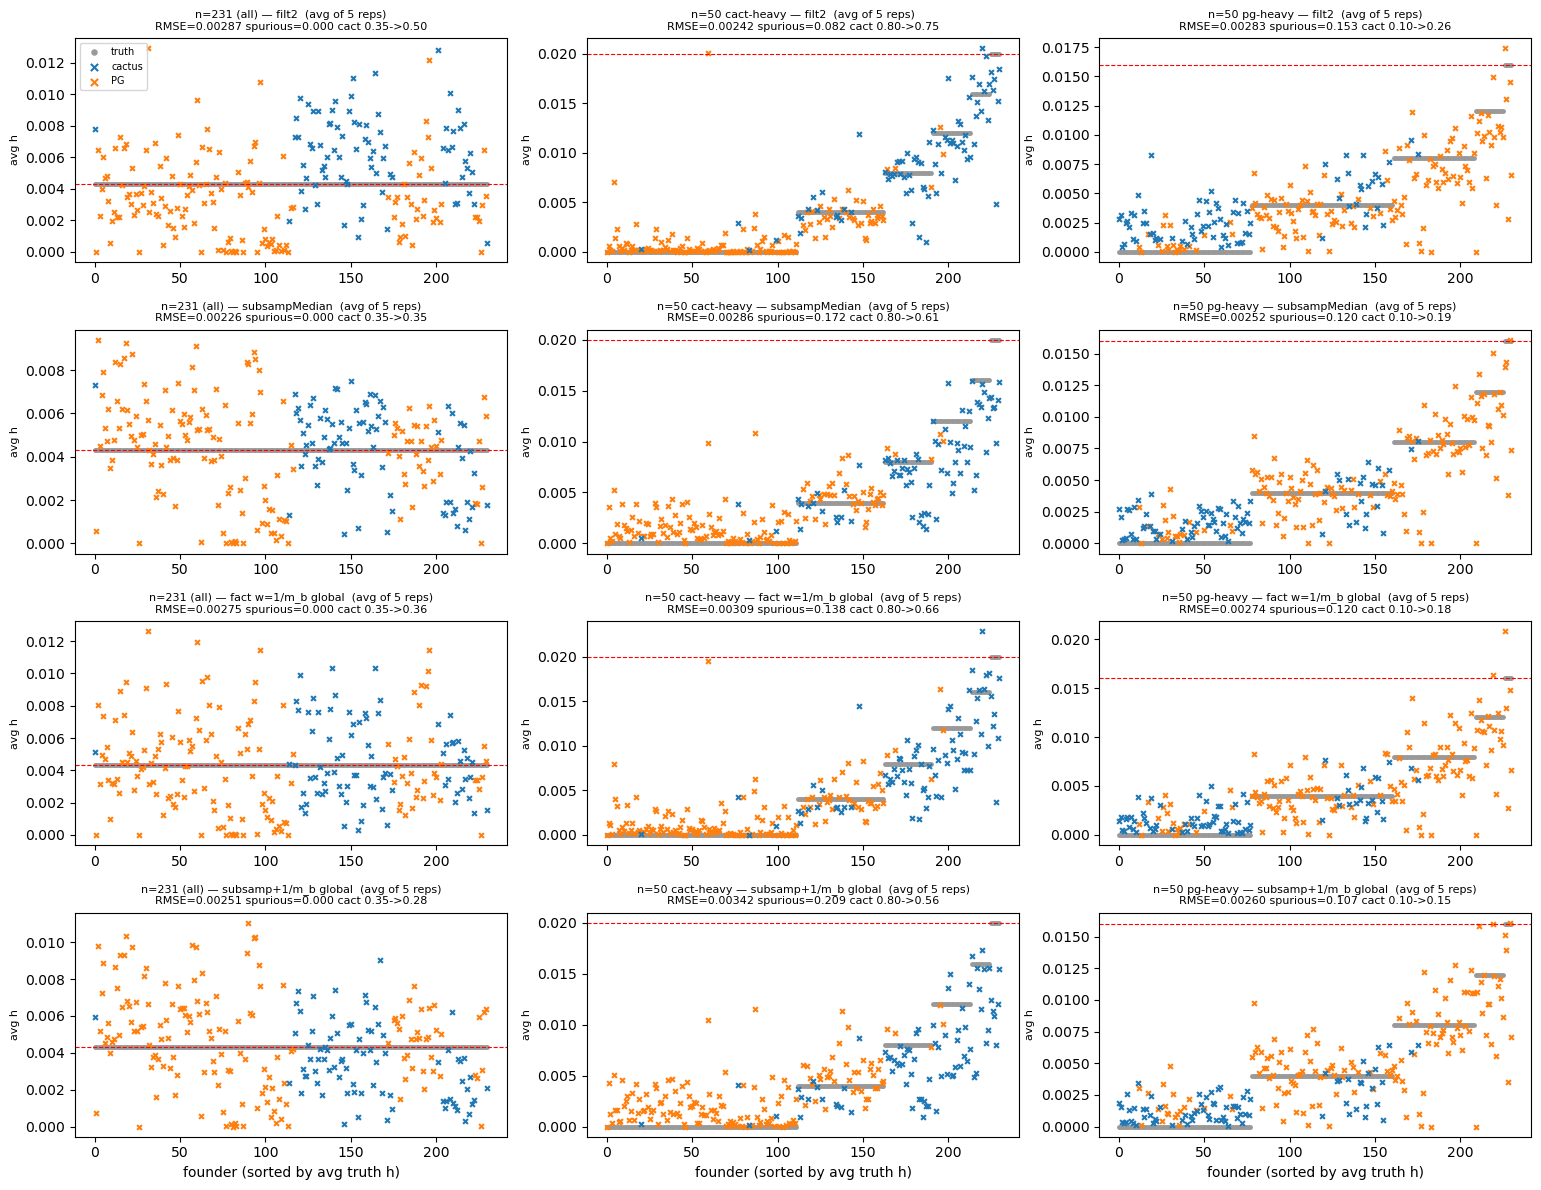

In [7]:
#!/usr/bin/env python3
"""Replicate-AVERAGED h grid (sorted-by-truth style). 4 methods x 3 regimes.
For each (method,regime): average per-founder h and per-founder truth over the 5 seeds,
then plot sorted by avg-truth; gray=truth, blue=cactus est, orange=PG est."""
import numpy as np, json, glob, os, math
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; HDIR=f"{ROOT}/scratch/h_fixes/replicates/h"
REPS=f"{ROOT}/sims/visor_freqk/g0_reps"
CAC=set(map(str,json.load(open(f"{ROOT}/data/founder_split_cactus_pg.json"))["cactus"]))
SEEDS=[101,102,103,104,105]
# (label, h-file tag)
M=[("filt2","filt2"),("subsampMedian","subsampMedian"),
   ("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
# (regime label, sim-name template)
R=[("n=231 (all)","g0_n231_rep{s}_rand"),("n=50 cact-heavy","g0_n50_rep{s}_cact"),
   ("n=50 pg-heavy","g0_n50_rep{s}_pg")]

def load_truth(sim):
    th={}
    p=f"{REPS}/{sim}/h_truth.tsv"
    if not os.path.exists(p): return None
    for ln in open(p):
        q=ln.split()
        if q and q[0]!="founder": th[q[0]]=float(q[1])
    return th

def avg_over_seeds(tag,tmpl):
    hs=[]; ths=[]; fo_ref=None
    for s in SEEDS:
        sim=tmpl.format(s=s); f=f"{HDIR}/{tag}__{sim}.npz"
        if not os.path.exists(f): continue
        d=np.load(f,allow_pickle=True); fo=np.asarray(d["founders"]).astype(str)
        fo_ref=fo; hs.append(np.asarray(d["h"]).astype(float))
        th=load_truth(sim); ths.append(np.array([th.get(x,0.0) for x in fo]))
    if not hs: return None
    return fo_ref, np.mean(hs,axis=0), np.mean(ths,axis=0), len(hs)

fig,ax=plt.subplots(len(M),len(R),figsize=(5.2*len(R),3.0*len(M)))
for ri,(mlab,tag) in enumerate(M):
    for ci,(rlab,tmpl) in enumerate(R):
        a=ax[ri,ci]; res=avg_over_seeds(tag,tmpl)
        if res is None: a.text(.5,.5,"n/a",ha="center",transform=a.transAxes); continue
        fo,h,t,nrep=res; cac=np.array([x in CAC for x in fo])
        order=np.argsort(t); h,t,cac=h[order],t[order],cac[order]; x=np.arange(len(fo))
        a.scatter(x,t,s=6,c="0.6",zorder=1,label="truth")
        a.scatter(x[cac],h[cac],s=12,marker="x",c="#1f77b4",zorder=3,label="cactus")
        a.scatter(x[~cac],h[~cac],s=12,marker="x",c="#ff7f0e",zorder=2,label="PG")
        lvl=t[t>0].max() if (t>0).any() else None
        if lvl: a.axhline(lvl,ls="--",lw=.8,c="r")
        rmse=math.sqrt(np.mean((h-t)**2)); spur=float(h[t==0].sum()); ct=t[cac].sum(); ce=h[cac].sum()
        a.set_title(f"{rlab} — {mlab}  (avg of {nrep} reps)\nRMSE={rmse:.5f} spurious={spur:.3f} cact {ct:.2f}->{ce:.2f}",fontsize=8)
        a.set_ylabel("avg h",fontsize=8)
        if ri==0 and ci==0: a.legend(fontsize=7,markerscale=1.5,loc="upper left")
for ci in range(len(R)): ax[-1,ci].set_xlabel("founder (sorted by avg truth h)")
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/H_VECTOR_grid_reps.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)

import matplotlib.pyplot as _plt; _plt.show()


## Replicate raw results (`replicates_df`) + mean±SD (`summary`)
Per-seed (101–105) cactus / RMSE / spurious for the 4 methods × 3 regimes.

In [8]:
# ---- replicates_df: raw per-seed results (5 seeds x 4 methods x 3 regimes) ----
import pandas as pd, glob, numpy as np
ROOT="/global/scratch/users/tbellg/kmate"
dfs=[pd.read_csv(p,sep="\t") for p in sorted(glob.glob(f"{ROOT}/scratch/h_fixes/replicates/results_*.tsv"))]
replicates_df=pd.concat(dfs,ignore_index=True)
replicates_df["seed"]=replicates_df["sim"].str.extract(r"rep(\d+)").astype(int)
def rg(s): return "g0_n231" if "n231" in s else ("g0_n50_cact" if "cact" in s else ("g0_n50_pg" if "pg" in s else "?"))
replicates_df["regime"]=replicates_df["sim"].map(rg)
replicates_df=replicates_df[["method","regime","seed","cactus","RMSE","spurious"]].sort_values(["method","regime","seed"]).reset_index(drop=True)
# mean +/- SD summary
summary=(replicates_df.groupby(["method","regime"])
         .agg(cactus_mean=("cactus","mean"),cactus_sd=("cactus","std"),
              RMSE_mean=("RMSE","mean"),RMSE_sd=("RMSE","std"),
              spurious_mean=("spurious","mean"),n=("seed","count")).round(5).reset_index())
print("replicates_df:",replicates_df.shape," | summary:",summary.shape)
print("\n=== mean +/- SD summary ==="); print(summary.to_string(index=False))
replicates_df    # raw per-seed table (display)


replicates_df: (60, 6)  | summary: (12, 8)

=== mean +/- SD summary ===
              method      regime  cactus_mean  cactus_sd  RMSE_mean  RMSE_sd  spurious_mean  n
 fact w=1/m_b global     g0_n231       0.3628    0.00455    0.00280  0.00003         0.0000  5
 fact w=1/m_b global g0_n50_cact       0.6578    0.00968    0.00388  0.00010         0.2152  5
 fact w=1/m_b global   g0_n50_pg       0.1830    0.00524    0.00406  0.00041         0.2504  5
               filt2     g0_n231       0.5000    0.00316    0.00293  0.00002         0.0000  5
               filt2 g0_n50_cact       0.7458    0.00507    0.00309  0.00024         0.1340  5
               filt2   g0_n50_pg       0.2640    0.00339    0.00402  0.00044         0.2466  5
subsamp+1/m_b global     g0_n231       0.2822    0.00327    0.00256  0.00003         0.0000  5
subsamp+1/m_b global g0_n50_cact       0.5576    0.01390    0.00455  0.00021         0.3266  5
subsamp+1/m_b global   g0_n50_pg       0.1486    0.00270    0.00418  0.00

,method,regime,seed,cactus,RMSE,spurious
0,fact w=1/m_b global,g0_n231,101,0.364,0.00280,0.000
1,fact w=1/m_b global,g0_n231,102,0.359,0.00284,0.000
2,fact w=1/m_b global,g0_n231,103,0.362,0.00281,0.000
3,fact w=1/m_b global,g0_n231,104,0.359,0.00277,0.000
4,fact w=1/m_b global,g0_n231,105,0.370,0.00280,0.000
5,fact w=1/m_b global,g0_n50_cact,101,0.649,0.00397,0.250
6,fact w=1/m_b global,g0_n50_cact,102,0.663,0.00386,0.199
7,fact w=1/m_b global,g0_n50_cact,103,0.647,0.00399,0.234
8,fact w=1/m_b global,g0_n50_cact,104,0.670,0.00374,0.174
9,fact w=1/m_b global,g0_n50_cact,105,0.660,0.00386,0.219


In [9]:
replicates_df.groupby(['regime','method'])['RMSE'].mean()

regime       method              
g0_n231      fact w=1/m_b global     0.002804
             filt2                   0.002928
             subsamp+1/m_b global    0.002558
             subsampMedian           0.002310
g0_n50_cact  fact w=1/m_b global     0.003884
             filt2                   0.003092
             subsamp+1/m_b global    0.004548
             subsampMedian           0.003924
g0_n50_pg    fact w=1/m_b global     0.004060
             filt2                   0.004024
             subsamp+1/m_b global    0.004180
             subsampMedian           0.004012
Name: RMSE, dtype: float64

## Allele-frequency comparison (h projected through arch3 cn_var)

The 2 finalist methods' h projected through the latest cn_var (cn_var_231_arch3_chr1, 2.62M records) → per-record AF, vs the true-pool-h projected through the same cn_var. 5-seed mean. `fact w=1/m_b global` (filt2+1/m_b, no deletion) wins AF in every regime. SV AF is more accurate than SNP AF.

In [10]:
import pandas as pd
af=pd.read_csv("/global/scratch/users/tbellg/kmate/scratch/h_fixes/replicates/af_results.tsv",sep="\t")
af_df=(af.groupby(["method","regime"])
       .agg(AF_MAE=("AF_MAE","mean"),AF_RMSE=("AF_RMSE","mean"),
            AF_MAE_SNP=("AF_MAE_SNP","mean"),AF_MAE_SV=("AF_MAE_SV","mean"),n=("AF_MAE","count"))
       .round(5).reset_index())
print(af_df.to_string(index=False))
af_df

              method   regime  AF_MAE  AF_RMSE  AF_MAE_SNP  AF_MAE_SV  n
 fact w=1/m_b global     n231 0.00653  0.01196     0.00663    0.00398  5
 fact w=1/m_b global n50_cact 0.00790  0.01466     0.00799    0.00432  5
 fact w=1/m_b global   n50_pg 0.01020  0.02426     0.01030    0.00713  5
subsamp+1/m_b global     n231 0.00707  0.01230     0.00713    0.00429  5
subsamp+1/m_b global n50_cact 0.01121  0.02084     0.01133    0.00602  5
subsamp+1/m_b global   n50_pg 0.01031  0.02491     0.01038    0.00725  5


,method,regime,AF_MAE,AF_RMSE,AF_MAE_SNP,AF_MAE_SV,n
0,fact w=1/m_b global,n231,0.00653,0.01196,0.00663,0.00398,5
1,fact w=1/m_b global,n50_cact,0.00790,0.01466,0.00799,0.00432,5
2,fact w=1/m_b global,n50_pg,0.01020,0.02426,0.01030,0.00713,5
3,subsamp+1/m_b global,n231,0.00707,0.01230,0.00713,0.00429,5
4,subsamp+1/m_b global,n50_cact,0.01121,0.02084,0.01133,0.00602,5
5,subsamp+1/m_b global,n50_pg,0.01031,0.02491,0.01038,0.00725,5


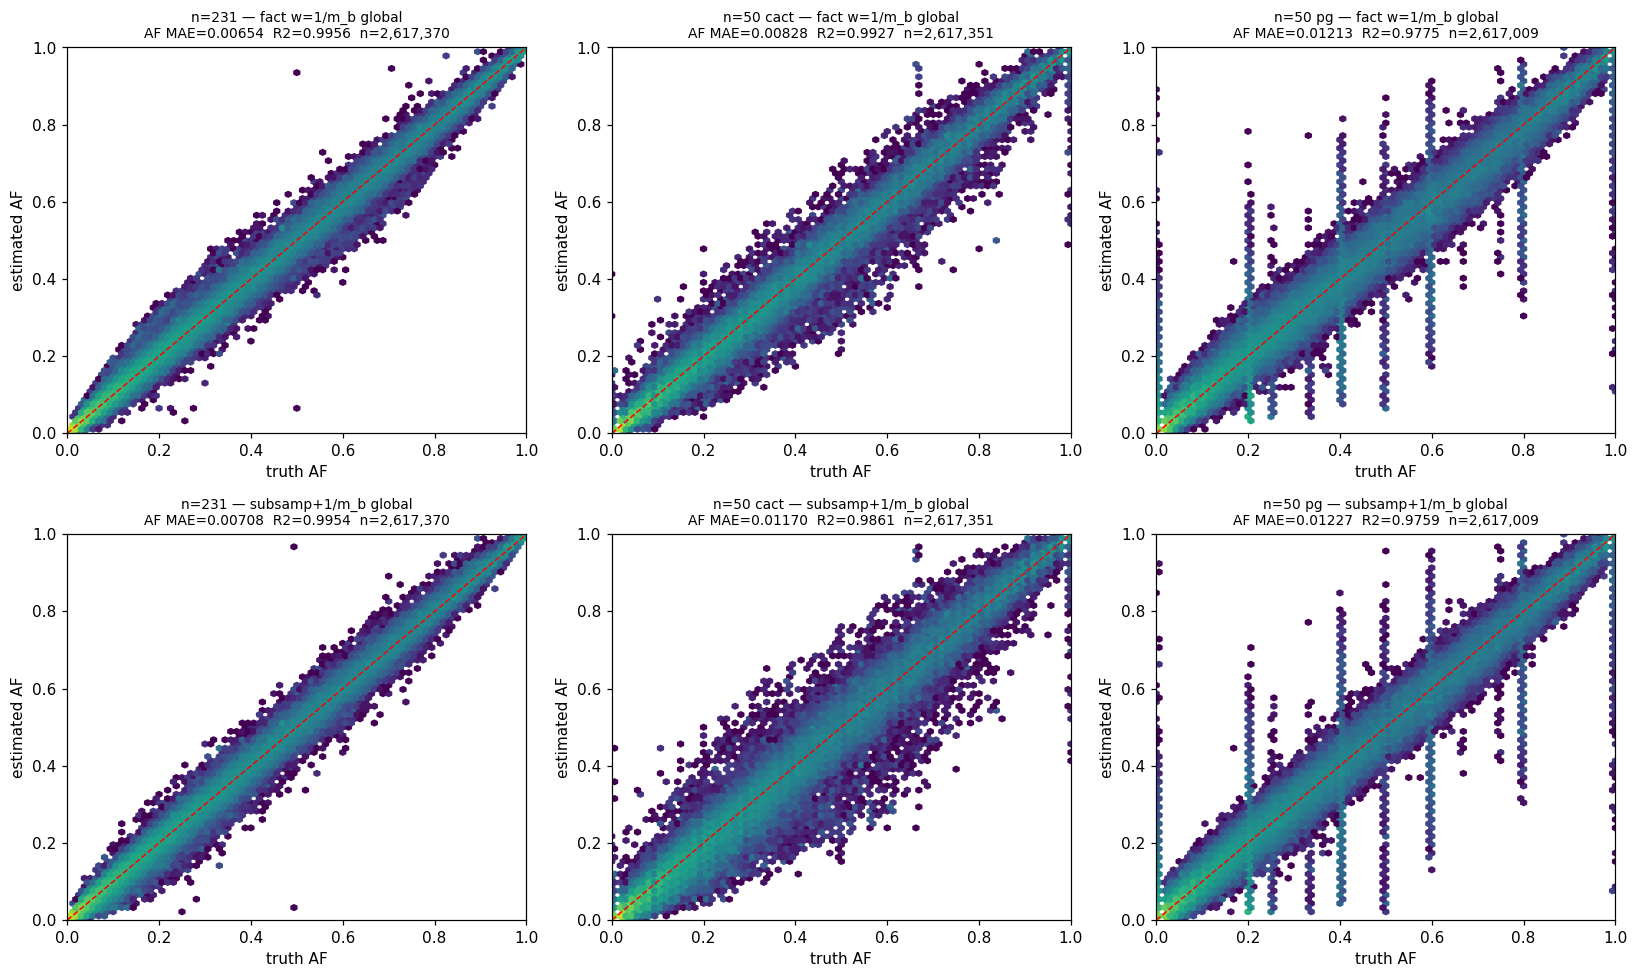

In [ ]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str)
fidx={f:i for i,f in enumerate(fo)}
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(len(fo))
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est.png"
import matplotlib.pyplot as _plt; _plt.show()


### AF scatter, missingness-filtered (records called in ≥50% of the 231 panel)

The vertical stripes in the n50_pg column are records where only a handful of present founders are genotyped. Direct check on `g0_n50_rep101_pg` (50 present founders): the dominant ~0.20 stripe (39,500 records) has median **5** present-called → `truth_AF = carriers/5` quantizes to {0, 0.2, 0.4, 0.6, 0.8}. (The smaller 0.25 / 0.333 / 0.5 stripes have ~40 present-called and are genuine, not artefacts — cross-check: records with ≥40 present-called show 17 distinct truth values in [0.18,0.22], records with ≤5 show 1.)

Filtering to records called in ≥50% of the 231 panel founders keeps **89.9%** of records and cuts n50_pg MAE ~25% (rep101: 0.0121 → 0.0092), while n231 / n50_cact are essentially unchanged — confirming the stripes are a pg-heavy missingness phenomenon, not a method failure.

loading cn_var...
records kept (<=50% missing): 2,354,304/2,617,370 (89.9%)
wrote /global/scratch/users/tbellg/kmate/notebooks/plots/af_true_vs_est_filt50.png


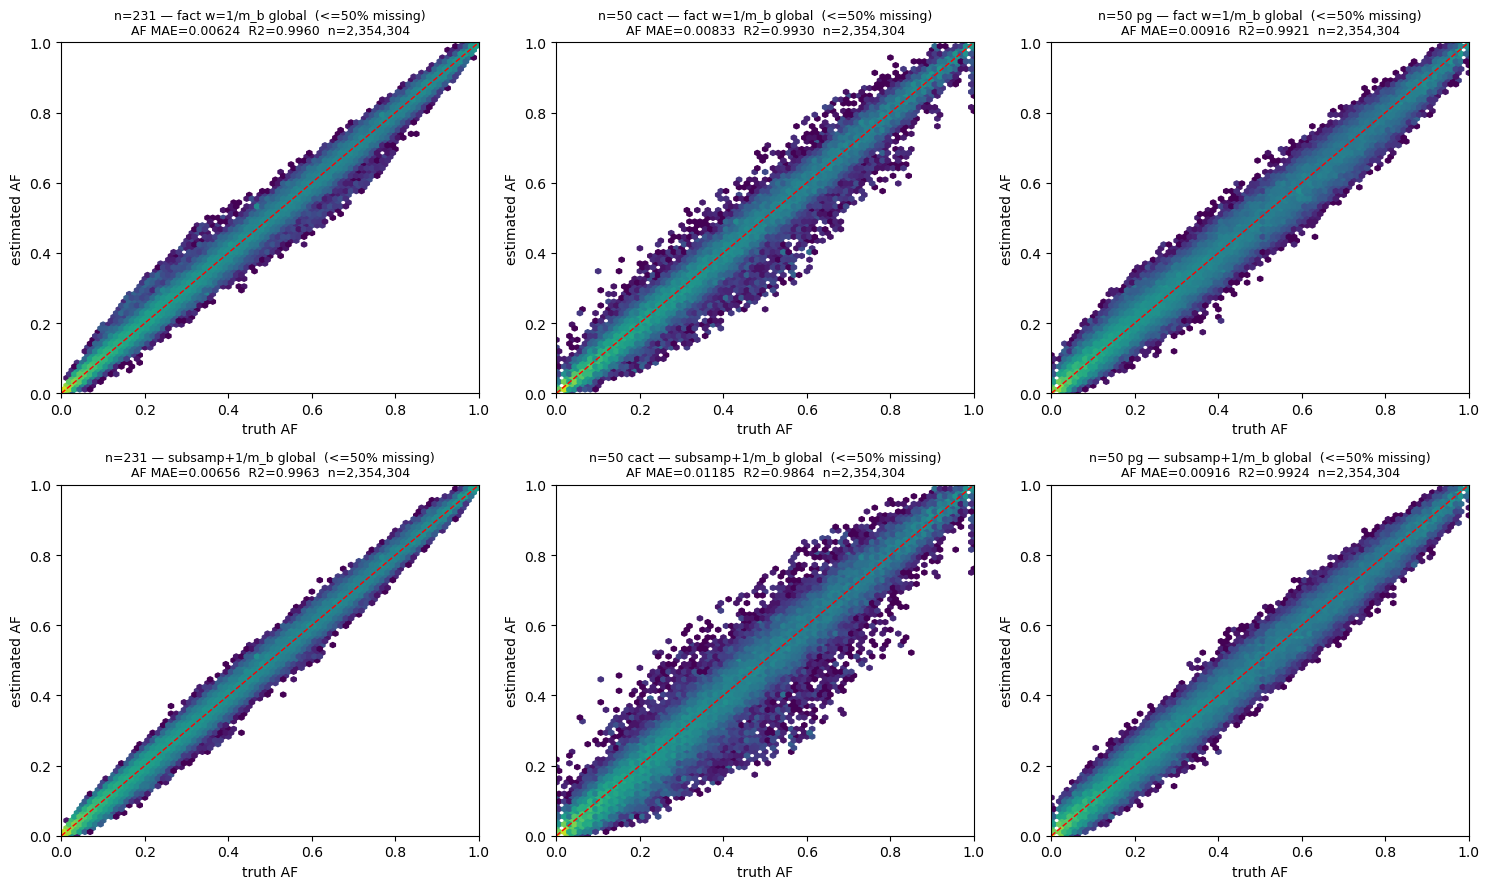

In [52]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str); F=len(fo)
fidx={f:i for i,f in enumerate(fo)}
ncalled=np.asarray(cn_called.sum(axis=0)).flatten()   # called founders per record (of 231)
keep=ncalled>=0.5*F                                    # keep records with <=50% missing
print(f"records kept (<=50% missing): {keep.sum():,}/{len(keep):,} ({100*keep.mean():.1f}%)")
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(F)
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&keep&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}  (<=50% missing)\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est_filt50.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)
import matplotlib.pyplot as _plt; _plt.show()


loading cn_var...
records kept (<=50% missing): 2,011,870/2,617,370 (76.9%)
wrote /global/scratch/users/tbellg/kmate/notebooks/plots/af_true_vs_est_filt50.png


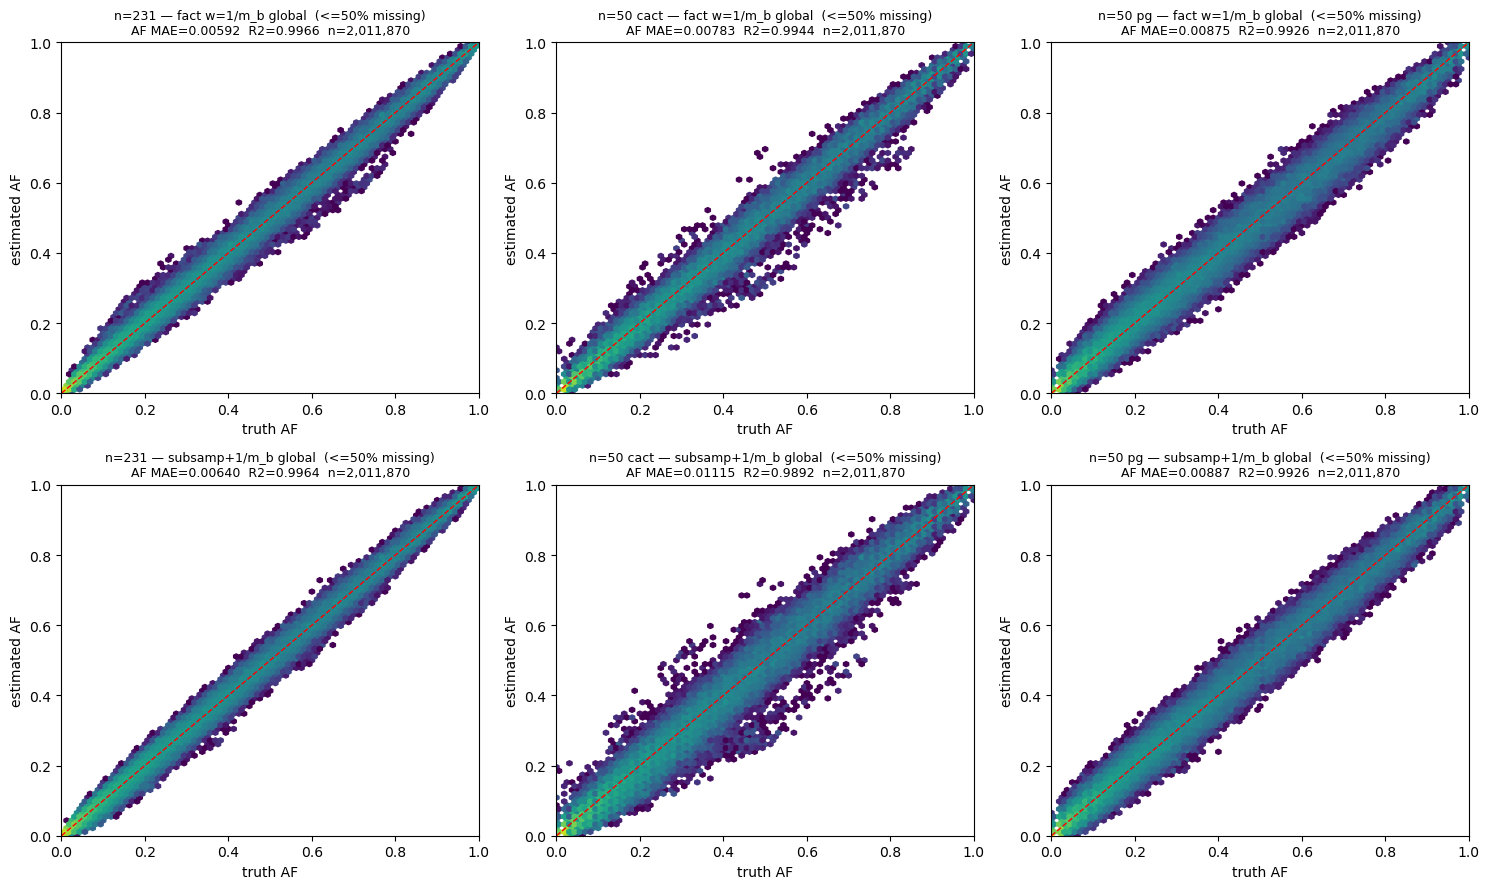

In [53]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str); F=len(fo)
fidx={f:i for i,f in enumerate(fo)}
ncalled=np.asarray(cn_called.sum(axis=0)).flatten()   # called founders per record (of 231)
keep=ncalled>=0.8*F                                    # keep records with <=50% missing
print(f"records kept (<=50% missing): {keep.sum():,}/{len(keep):,} ({100*keep.mean():.1f}%)")
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(F)
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&keep&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}  (<=50% missing)\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est_filt50.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)
import matplotlib.pyplot as _plt; _plt.show()


loading cn_var...
records kept (<=50% missing): 1,547,457/2,617,370 (59.1%)
wrote /global/scratch/users/tbellg/kmate/notebooks/plots/af_true_vs_est_filt50.png


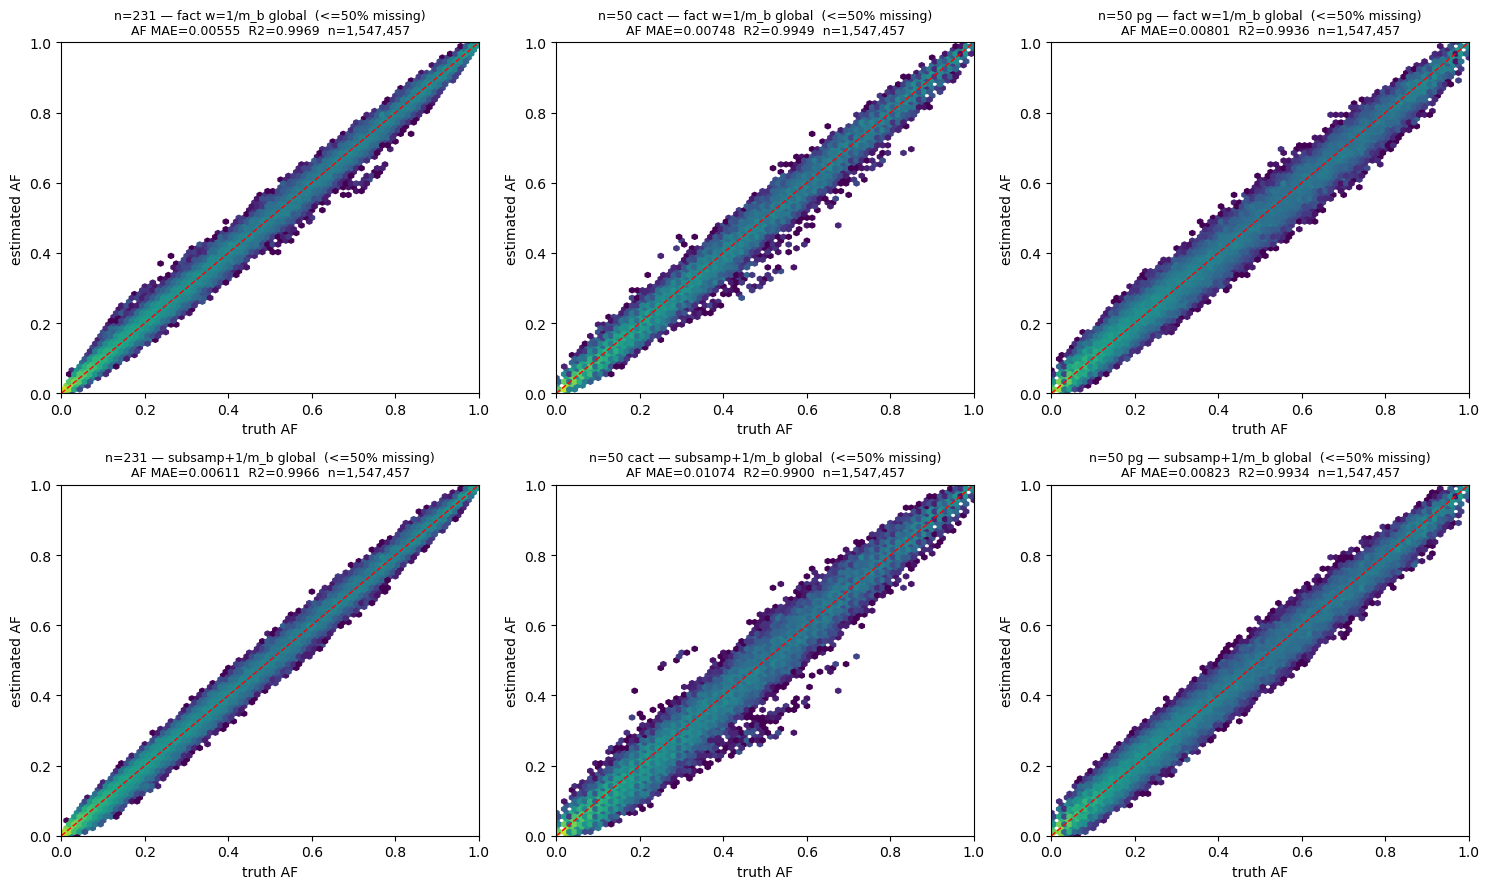

In [54]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str); F=len(fo)
fidx={f:i for i,f in enumerate(fo)}
ncalled=np.asarray(cn_called.sum(axis=0)).flatten()   # called founders per record (of 231)
keep=ncalled>=0.9*F                                    # keep records with <=50% missing
print(f"records kept (<=50% missing): {keep.sum():,}/{len(keep):,} ({100*keep.mean():.1f}%)")
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(F)
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&keep&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}  (<=50% missing)\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est_filt50.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)
import matplotlib.pyplot as _plt; _plt.show()


loading cn_var...
records kept (<=50% missing): 1,322,837/2,617,370 (50.5%)
wrote /global/scratch/users/tbellg/kmate/notebooks/plots/af_true_vs_est_filt50.png


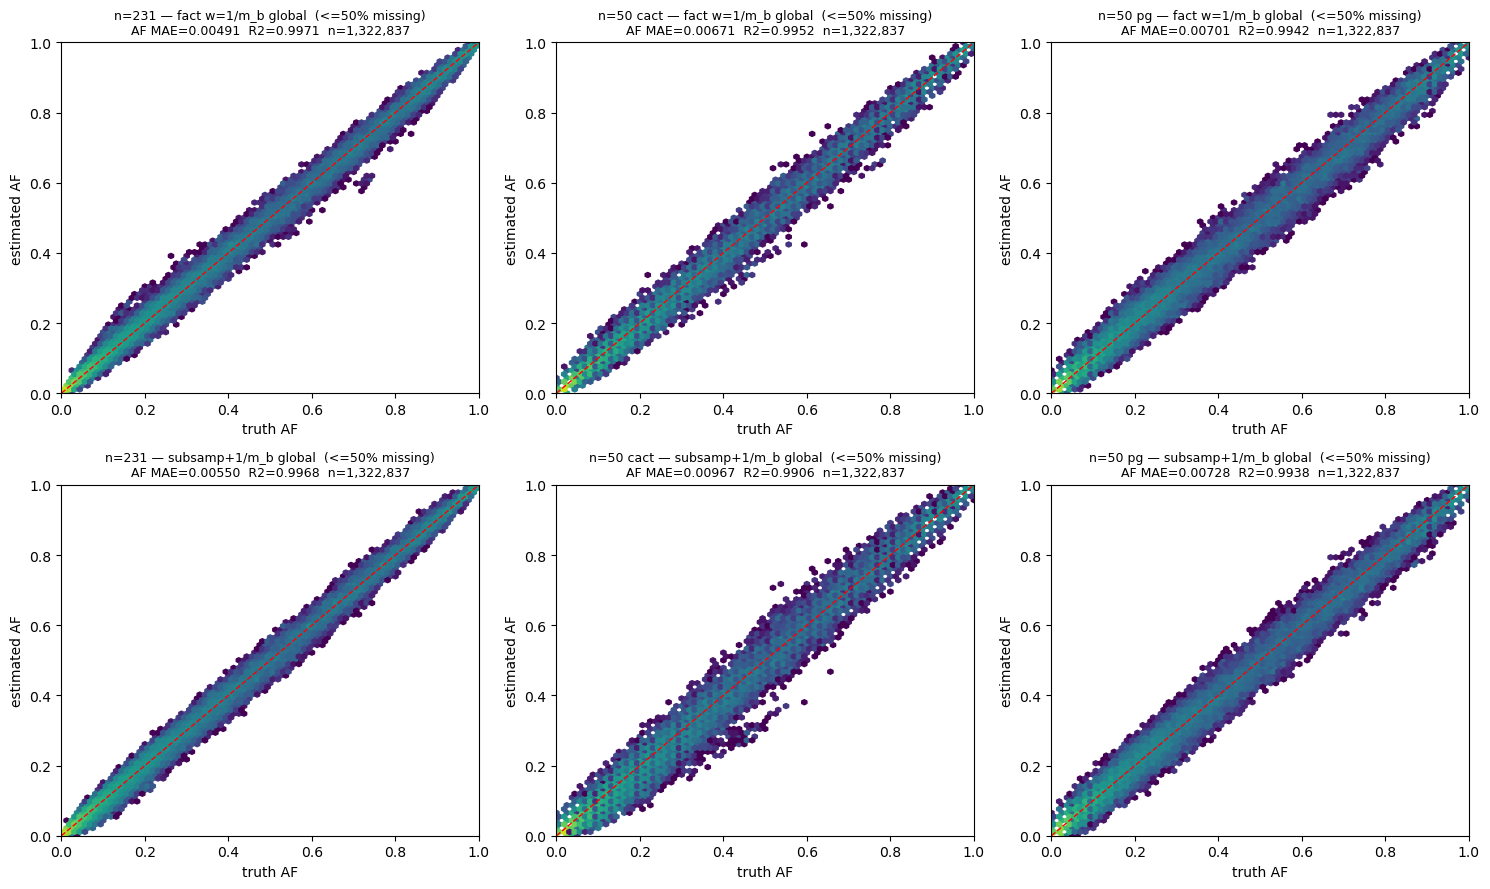

In [56]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str); F=len(fo)
fidx={f:i for i,f in enumerate(fo)}
ncalled=np.asarray(cn_called.sum(axis=0)).flatten()   # called founders per record (of 231)
keep=ncalled>=0.95*F                                    # keep records with <=50% missing
print(f"records kept (<=50% missing): {keep.sum():,}/{len(keep):,} ({100*keep.mean():.1f}%)")
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(F)
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&keep&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}  (<=50% missing)\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est_filt50.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)
import matplotlib.pyplot as _plt; _plt.show()


loading cn_var...
records kept (<=50% missing): 974,607/2,617,370 (37.2%)
wrote /global/scratch/users/tbellg/kmate/notebooks/plots/af_true_vs_est_filt50.png


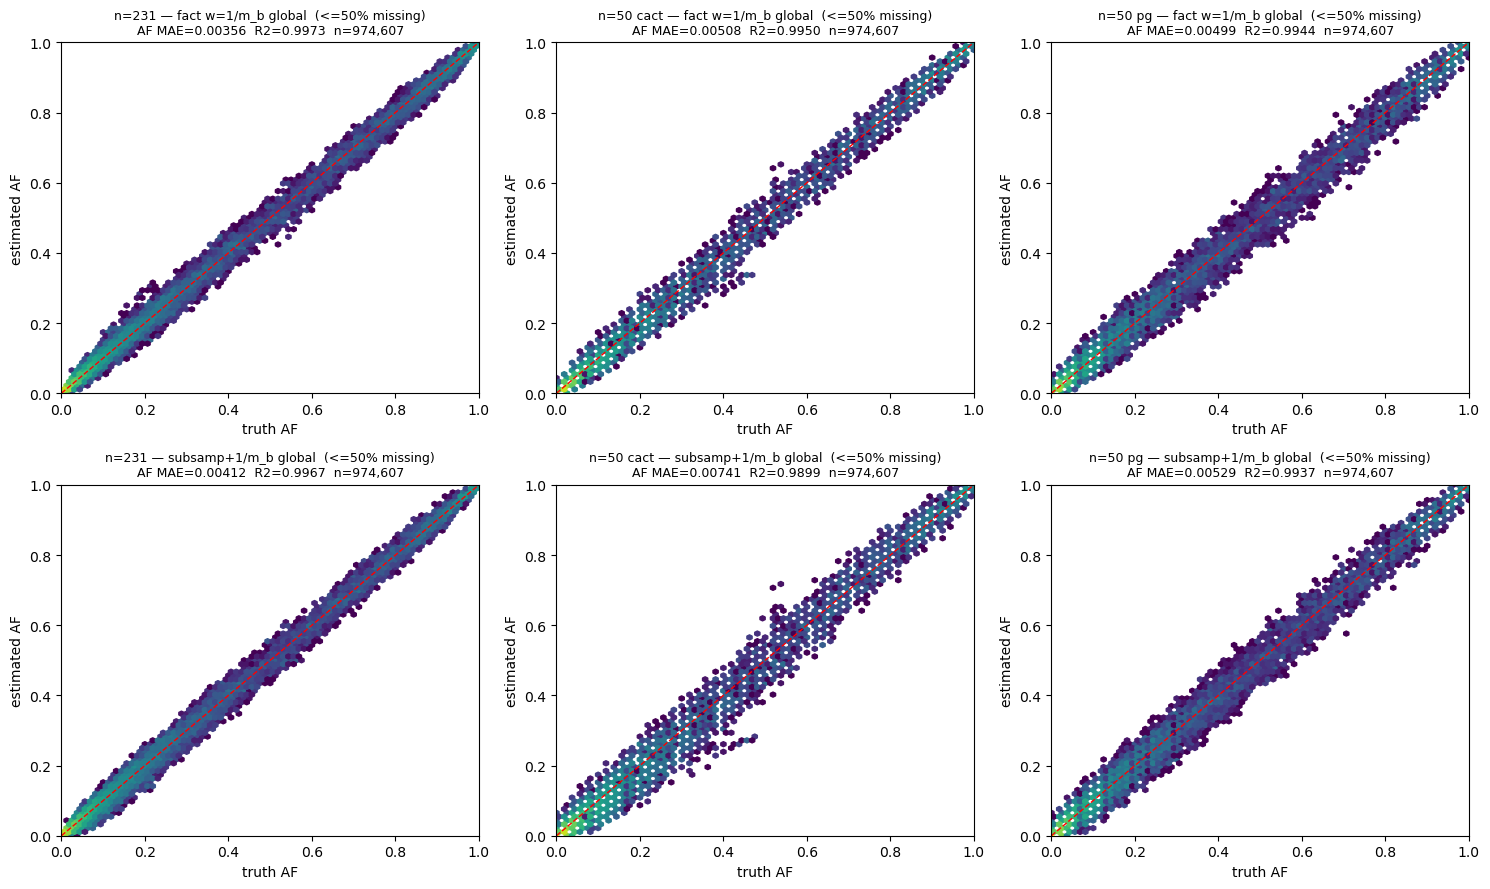

In [57]:
import numpy as np, os, math
from scipy.sparse import load_npz
import matplotlib; import matplotlib.pyplot as plt
ROOT="/global/scratch/users/tbellg/kmate"; CV=f"{ROOT}/panel/arch3/chr1/cn_var_231_arch3_chr1"
print("loading cn_var...",flush=True)
cn_var=load_npz(f"{CV}.cn_var.npz").tocsc(); cn_called=load_npz(f"{CV}.cn_var_called.npz").tocsc()
fo=np.asarray(np.load(f"{CV}.meta.npz",allow_pickle=True)["founders"]).astype(str); F=len(fo)
fidx={f:i for i,f in enumerate(fo)}
ncalled=np.asarray(cn_called.sum(axis=0)).flatten()   # called founders per record (of 231)
keep=ncalled>=0.99*F                                    # keep records with <=50% missing
print(f"records kept (<=50% missing): {keep.sum():,}/{len(keep):,} ({100*keep.mean():.1f}%)")
def proj(h): return cn_var.T.dot(h), cn_called.T.dot(h)
def htrue(sim):
    h=np.zeros(F)
    for ln in open(f"{ROOT}/sims/visor_freqk/g0_reps/{sim}/h_truth.tsv"):
        p=ln.split()
        if p and p[0]!="founder" and p[0] in fidx: h[fidx[p[0]]]=float(p[1])
    return h
METH=[("fact w=1/m_b global","fact_w=1m_b_global"),("subsamp+1/m_b global","subsamp1m_b_global")]
COLS=[("n=231","g0_n231_rep101_rand"),("n=50 cact","g0_n50_rep101_cact"),("n=50 pg","g0_n50_rep101_pg")]
fig,ax=plt.subplots(len(METH),len(COLS),figsize=(5*len(COLS),4.5*len(METH)))
for ci,(rlab,sim) in enumerate(COLS):
    nt,dt=proj(htrue(sim)); vt=dt>1e-9; truth=np.where(vt,nt/np.maximum(dt,1e-12),np.nan)
    for ri,(mlab,tag) in enumerate(METH):
        a=ax[ri,ci]; hp=f"{ROOT}/scratch/h_fixes/replicates/h/{tag}__{sim}.npz"
        he=np.asarray(np.load(hp,allow_pickle=True)["h"]).astype(float)
        ne,de=proj(he); ve=de>1e-9; est=np.where(ve,ne/np.maximum(de,1e-12),np.nan)
        m=vt&ve&keep&~np.isnan(truth)&~np.isnan(est); x=truth[m]; y=est[m]
        mae=np.abs(x-y).mean(); r2=np.corrcoef(x,y)[0,1]**2
        a.hexbin(x,y,gridsize=80,bins="log",cmap="viridis",mincnt=1)
        a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{rlab} — {mlab}  (<=50% missing)\nAF MAE={mae:.5f}  R2={r2:.4f}  n={m.sum():,}",fontsize=9)
fig.tight_layout(); out=f"{ROOT}/notebooks/plots/af_true_vs_est_filt50.png"
fig.savefig(out,dpi=110,bbox_inches="tight"); print("wrote",out)
import matplotlib.pyplot as _plt; _plt.show()


## Missingness CDF — how many records a missing-row filter would cost

Per-record missing count = 231 − (#founders called) on the arch3 cn_var (`cn_var_231_arch3_chr1`, R=2,617,370). The curve is **bimodal**: climbs to ~85% by ≤58 missing, then is **flat from ~58 to ~150** (almost no records in that band), then a cliff near ~150–160. Records are either well-called (≤58 missing, 85.5%) or catastrophically missing (>150 missing, last ~10%); any cut inside the plateau costs the same ~10–15% of records.

| max # missing | % founders | kept | **LOST** |
|---|---|---|---|
| ≤0 | 0% | 666,631 (25.5%) | 1,950,739 (74.5%) |
| ≤16 | 6.9% | 1,424,612 (54.4%) | 1,192,758 (45.6%) |
| ≤40 | 17.3% | 1,877,000 (71.7%) | 740,370 (28.3%) |
| ≤58 | 25% | 2,237,635 (85.5%) | 379,735 (14.5%) |
| **≤115 (the 50% filter)** | **50%** | **2,354,304 (89.9%)** | **263,066 (10.1%)** |

NOTE: raw arch3 (2.62M). On the atomized matrix (7.46M) fractions should be nearly identical (atomization inherits the parent called-mask) but absolute counts scale ~2.85×.

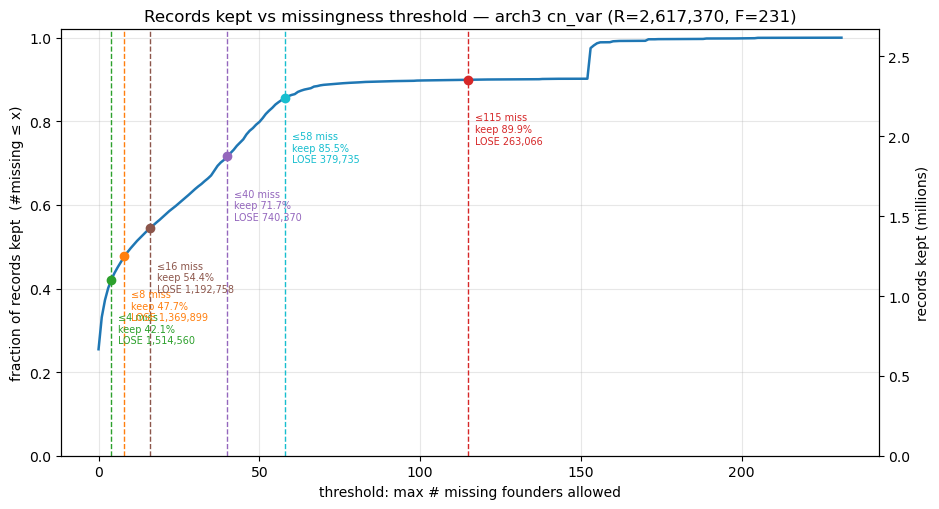

In [58]:
import numpy as np
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
CV="/global/scratch/users/tbellg/kmate/panel/arch3/chr1/cn_var_231_arch3_chr1"
cnc=load_npz(f"{CV}.cn_var_called.npz").tocsc(); F,R=cnc.shape
called=np.asarray(cnc.sum(axis=0)).ravel().astype(int)
miss=F-called                       # # missing founders per record
thr=np.arange(0,F+1); order=np.sort(miss)
keptf=np.searchsorted(order,thr,side="right")/R
fig,ax=plt.subplots(figsize=(9.5,5.2))
ax.plot(thr,keptf,lw=1.8,color="#1f77b4")
ax.set_xlabel("threshold: max # missing founders allowed")
ax.set_ylabel("fraction of records kept  (#missing \u2264 x)")
ax.set_title(f"Records kept vs missingness threshold — arch3 cn_var (R={R:,}, F={F})")
ax.set_ylim(0,1.02); ax.grid(alpha=.3)
marks=[4,8,16,40,58,115]; colors=["#2ca02c","#ff7f0e","#8c564b","#9467bd","#17becf","#d62728"]
for t,c in zip(marks,colors):
    kn=int((miss<=t).sum()); kf=kn/R; lost=R-kn
    ax.axvline(t,ls="--",lw=1,color=c); ax.plot(t,kf,"o",color=c,ms=6)
    ax.annotate(f"\u2264{t} miss\nkeep {kf*100:.1f}%\nLOSE {lost:,}",(t,kf),
                textcoords="offset points",xytext=(5,-46),fontsize=7,color=c)
ax2=ax.twinx(); ax2.set_ylim(0,1.02*R/1e6); ax2.set_ylabel("records kept (millions)")
fig.tight_layout()
fig.savefig("/global/scratch/users/tbellg/kmate/notebooks/plots/missingness_cdf_arch3.png",dpi=120,bbox_inches="tight")
plt.show()